# Evaluacion de los modelos

Compara los tres modelos entrenados en el cuaderno anterior sobre el mismo
conjunto de prueba, calcula todas las metricas que pide el enunciado y analiza
los dos tipos de error desde el contexto ambiental del problema.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
if not (ROOT / 'src').is_dir():
    ROOT = ROOT.parent
if not (ROOT / 'src').is_dir():
    raise RuntimeError('Abra Jupyter desde la raiz de Laboratorio 4')

sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
from IPython.display import Image, display

import warnings
warnings.filterwarnings('ignore')

from src import evaluacion as ev
from src import modelos as md

print(f'Metrica principal de comparacion: {ev.METRICA_PRINCIPAL.upper()}')

Metrica principal de comparacion: F2


## 1. Metricas sobre el conjunto de prueba

Accuracy, Precision, Recall, F1, ROC-AUC y matriz de confusion de cada modelo,
mas dos metricas adicionales.

**F2** porque el error costoso es el falso negativo, como se argumenta en la
seccion 3. **PR-AUC**, la precision media, porque con 1.29 por ciento de
positivos ROC-AUC se ve favorecido por la enorme cantidad de negativos faciles y
puede parecer excelente aunque el modelo funcione mal sobre la clase que importa.

In [2]:
resultado = ev.evaluar_y_exportar()
metricas = pd.DataFrame(resultado['filas']).set_index('modelo')

display(metricas[['n_prueba', 'positivos_prueba', 'accuracy', 'precision',
                  'recall', 'f1', 'f2', 'roc_auc', 'pr_auc']])

,n_prueba,positivos_prueba,accuracy,precision,recall,f1,f2,roc_auc,pr_auc
modelo,,,,,,,,,
regresion_logistica,147799,1910,0.972334,0.316490,0.983770,0.478909,0.691979,0.996944,0.824138
random_forest,147799,1910,0.997219,0.838987,0.971204,0.900267,0.941529,0.999702,0.979400
gradient_boosting,147799,1910,0.998261,0.898313,0.975916,0.935508,0.959341,0.999830,0.987989


Matrices de confusion


,verdaderos_negativos,falsos_positivos,falsos_negativos,verdaderos_positivos
modelo,,,,
regresion_logistica,141831,4058,31,1879
random_forest,145533,356,55,1855
gradient_boosting,145678,211,46,1864


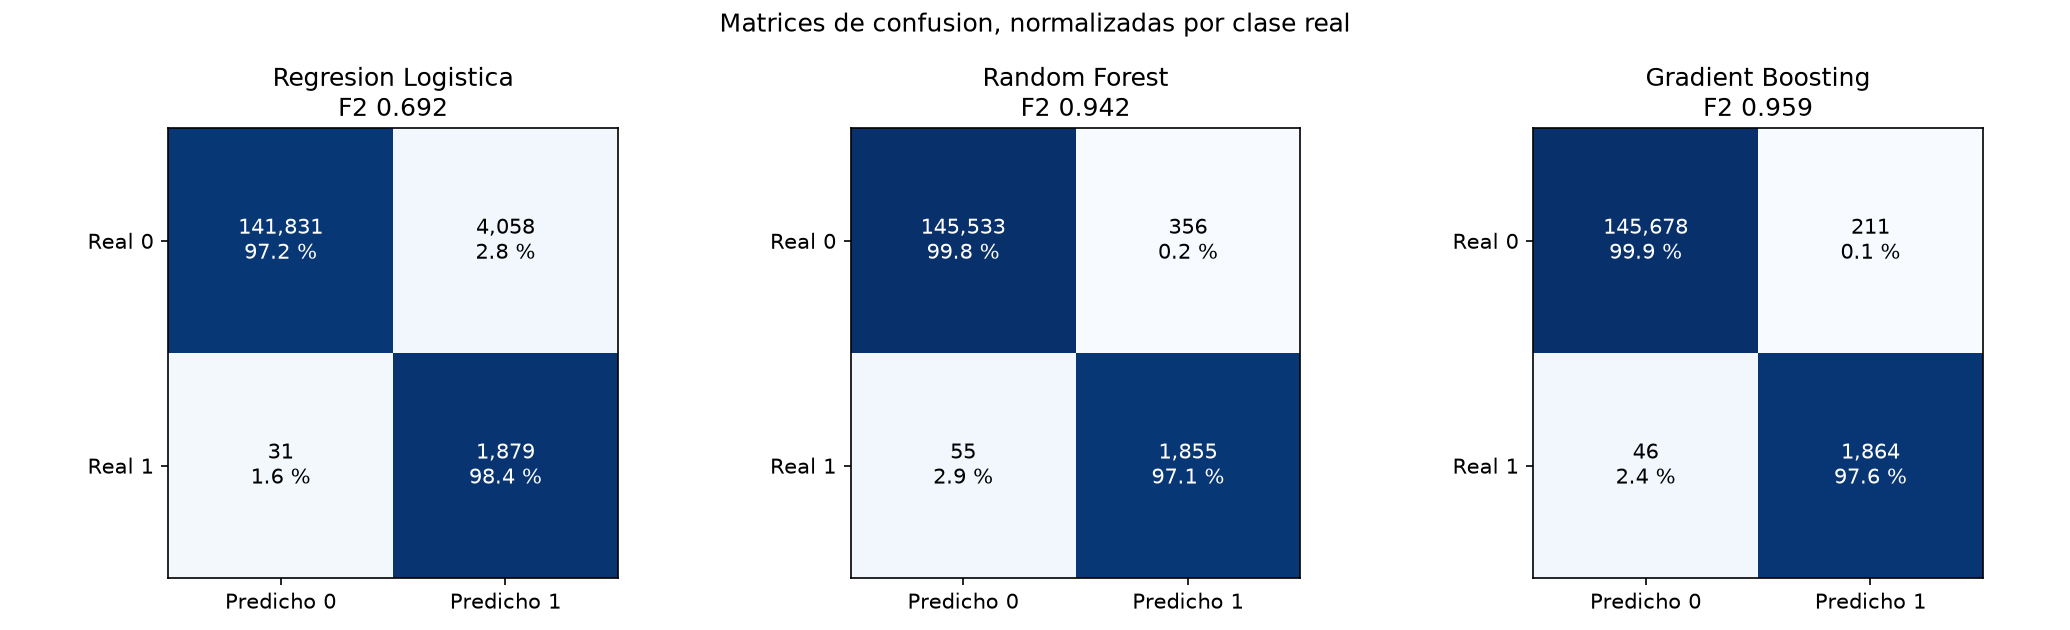

In [3]:
print('Matrices de confusion')
display(metricas[['verdaderos_negativos', 'falsos_positivos',
                  'falsos_negativos', 'verdaderos_positivos']])
display(Image(filename=str(ROOT / 'results' / 'figures' / 'matrices_confusion.png')))

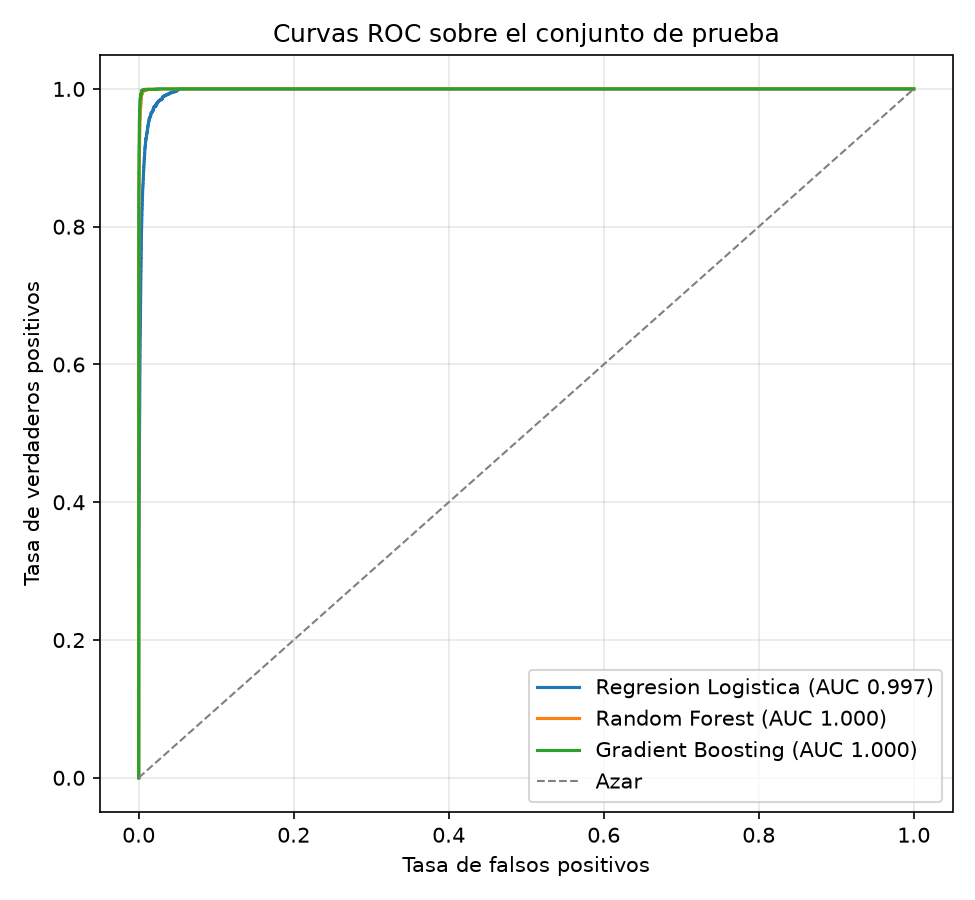

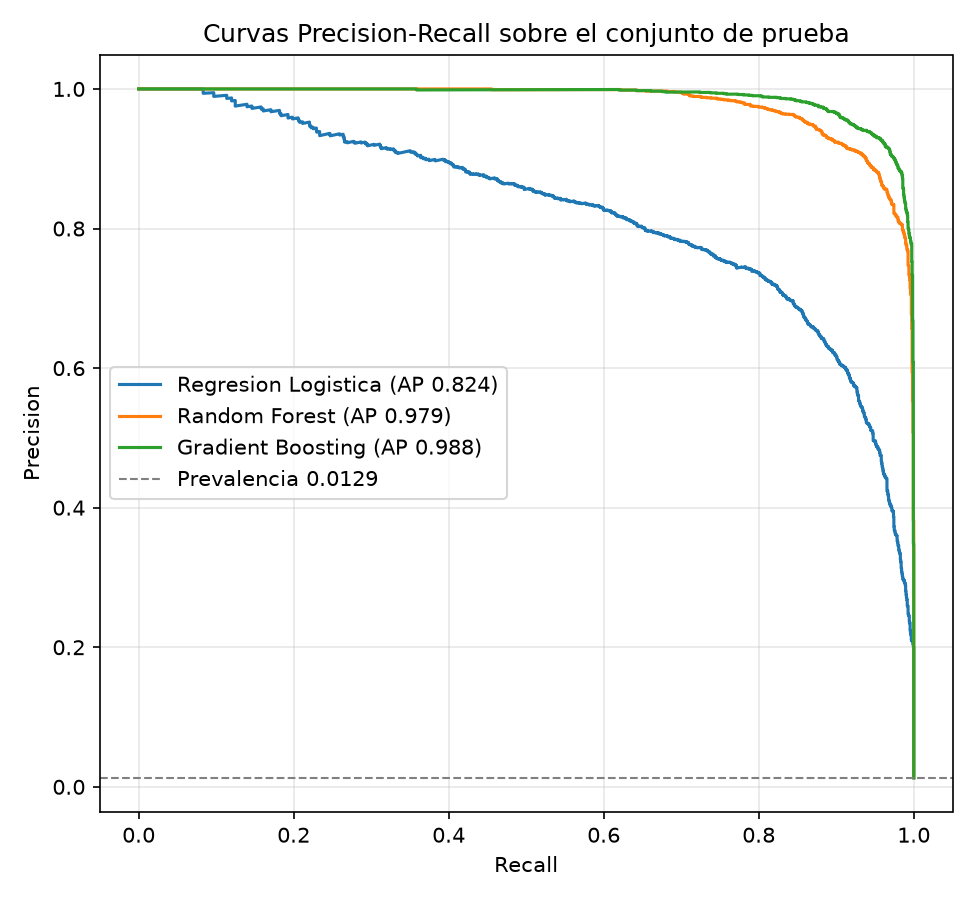

In [4]:
display(Image(filename=str(ROOT / 'results' / 'figures' / 'curvas_roc.png')))
display(Image(filename=str(ROOT / 'results' / 'figures' / 'curvas_precision_recall.png')))

## 2. Comparacion entre modelos

Que modelo gana depende de la metrica que se mire, asi que conviene verlo
explicito antes de declarar un ganador.

In [5]:
por_criterio = pd.Series(resultado['por_criterio'], name='mejor modelo').to_frame()
display(por_criterio)

print(f"Mejor modelo segun {ev.METRICA_PRINCIPAL.upper()}: {resultado['mejor']}")

,mejor modelo
accuracy,gradient_boosting
precision,gradient_boosting
recall,regresion_logistica
f1,gradient_boosting
f2,gradient_boosting
roc_auc,gradient_boosting
pr_auc,gradient_boosting


Mejor modelo segun F2: gradient_boosting


La Regresion Logistica alcanza el Recall mas alto, pero a costa de una Precision
muy baja: marca como alta presencia una cantidad enorme de celdas que no lo son.
Los dos modelos de arboles conservan casi el mismo Recall con mucha mas
Precision, y el Gradient Boosting es el mejor en casi todos los criterios.

Vale la pena notar que Accuracy no discrimina: los tres superan el 98 por ciento
simplemente porque el 98.7 por ciento de las celdas es negativo. Esa es la razon
concreta por la que no puede ser el criterio de comparacion.

## 3. Los dos errores desde el contexto ambiental

El enunciado pide analizar que consecuencias tiene clasificar como alta presencia
una zona que no la tiene, y no detectar una zona que si la presenta, y decidir
cual de los dos errores importa mas reducir.

**Falso positivo.** El modelo marca alta presencia donde no la hay. El costo es
operativo: se moviliza un muestreo de campo innecesario, o se emite una
advertencia que despues no se sostiene. Si se repite, erosiona la confianza en el
sistema de alerta, pero no genera exposicion.

**Falso negativo.** El modelo no detecta una zona que si tiene alta presencia de
cianobacteria. El costo es de salud publica: una floracion que puede producir
cianotoxinas queda sin alerta, y esa agua se usa para recreacion, pesca, riego y
abastecimiento. La OMS clasifica los 10 microgramos por litro de clorofila-a
asociada a dominancia de cianobacterias como Alert Level 1 precisamente porque a
partir de ahi se recomienda vigilancia activa e informacion al publico.

Los dos errores no son simetricos. En monitoreo ambiental de riesgo sanitario, el
costo de no advertir supera al de advertir de mas, y una herramienta de apoyo al
monitoreo se disena para reducir el primero.

**De ahi se sigue la eleccion de metrica.** Ni Accuracy ni F1 sirven: la primera
esta dominada por los negativos y la segunda pesa igual Precision y Recall. La
metrica adecuada es **F2**, que con beta = 2 pesa el Recall cuatro veces mas que
la Precision. Es la metrica con la que se ajustaron los hiperparametros y con la
que se compara aqui.

In [6]:
costos = pd.DataFrame(resultado['costos']).set_index('modelo')
display(costos)

,falsos_negativos,pct_positivos_no_detectados,falsos_positivos,inspecciones_innecesarias_por_zona_detectada
modelo,,,,
regresion_logistica,31,1.6230,4058,2.1597
random_forest,55,2.8796,356,0.1919
gradient_boosting,46,2.4084,211,0.1132


La segunda columna es la que importa leer en clave ambiental: que porcentaje de
las zonas con alta presencia real quedaria sin detectar. La ultima columna dice
cuantas inspecciones innecesarias cuesta cada zona correctamente detectada, que
es el precio operativo de ese Recall.

## 4. Diagnostico: cuanto del desempeno es firma espectral

Las metricas de arriba son altas. Antes de darlas por buenas conviene comprobar
de donde viene ese desempeno, porque hay una via facil que el modelo podria estar
tomando.

Amatitlan tiene 10.48 por ciento de celdas positivas y Atitlan 0.0016 por ciento,
siete de 432 mil. Con esa asimetria, saber en que lago esta una celda es casi
saber la respuesta. Y el modelo tiene cuatro formas de saberlo: los dos one-hot
de lago y, de manera implicita, `x_utm` e `y_utm`, porque los dos lagos ocupan
rangos de coordenadas disjuntos y un solo corte los separa.

El diagnostico reentrena cada modelo sin esas cuatro columnas, conservando sus
hiperparametros, y compara contra el modelo completo sobre el mismo conjunto de
prueba. Hay que quitar las cuatro a la vez: retirar solo los one-hot no mide nada
porque el modelo se pasa a `x_utm` y el desempeno no se mueve.

In [7]:
diagnostico = pd.DataFrame(resultado['diagnostico_lago'])
display(diagnostico.pivot(index='metrica', columns='modelo',
                          values=['con_ubicacion', 'sin_ubicacion']).round(4))

con_ubicacion                                    \
modelo    gradient_boosting random_forest regresion_logistica   
metrica                                                         
f2                   0.9593        0.9415              0.6920   
pr_auc               0.9880        0.9794              0.8241   
precision            0.8983        0.8390              0.3165   
recall               0.9759        0.9712              0.9838   
roc_auc              0.9998        0.9997              0.9969   

              sin_ubicacion                                    
modelo    gradient_boosting random_forest regresion_logistica  
metrica                                                        
f2                   0.9444        0.9259              0.5933  
pr_auc               0.9790        0.9640              0.5457  
precision            0.8520        0.7897              0.2294  
recall               0.9707        0.9675              0.9832  
roc_auc              0.9997        0.9995              0.9911

Los dos modelos de arboles conservan casi todo su desempeno sin saber en que lago
estan, asi que su capacidad predictiva viene de la firma espectral y de las
variables derivadas, no de un atajo geografico. La Regresion Logistica es la que
mas depende de la ubicacion, y su PR-AUC cae de forma notable al quitarsela.

Este diagnostico no reemplaza a la validacion espacial ni a la generalizacion
entre lagos, que son las que van a poner a prueba de verdad estas cifras. Lo que
si establece es que el modelo no esta ganando por el atajo mas obvio.

**Una advertencia sobre estos numeros.** La division 70/30 es aleatoria, y celdas
de 50 metros contiguas de la misma fecha son casi el mismo pixel. Eso significa
que muchas observaciones del conjunto de prueba tienen una vecina casi identica
en el de entrenamiento, y que estas metricas son con toda probabilidad
optimistas. Cuantificar esa diferencia es exactamente lo que hace la validacion
espacial en el ejercicio siguiente.

## 5. Verificacion del contrato

Comprueba que los tres modelos se evaluaron sobre el mismo conjunto de prueba,
que las matrices de confusion cuadran con el numero de observaciones y de
positivos, que ninguna metrica cae fuera del rango de 0 a 1 y que las figuras y
el diagnostico existen.

In [8]:
verificacion = ev.verificar_evaluacion()
print(f"Modelos evaluados: {verificacion['modelos']}")
print(f"Mejor modelo:      {verificacion['mejor']}")

Modelos evaluados: 3
Mejor modelo:      gradient_boosting
